In [50]:
# Hello! I am a test cell. You can run me to see if your Python environment is working.
# Try pressing 'Ctrl + Enter' and see if you can see the message below.

print("If it is working, it is working. If it is not, it is not.")

If it is working, it is working. If it is not, it is not.


### The Bar Plot

Displays data using rectangular bars, where the *height* or *length* of the bars represents the magnitude of the data.

**Use cases:**

- Ideal for comparing different categories or groups.

- Displays discrete data that has distinct categories.
    - Example: Comparing sales revenue by product.

- Shows how different categories contribute to a whole.
    - Example: Sales percentages or budget allocations.

- Visualizes data that can be easily ranked or ordered.
    - Example: Displaying the best-selling books in a market.

Their simplicity and interpretability make bar plots one of the most used types of plots in data visualization.

Attention: Inaccurate bar choices or axis scales can lead to misleading plots.

<BarContainer object of 5 artists>

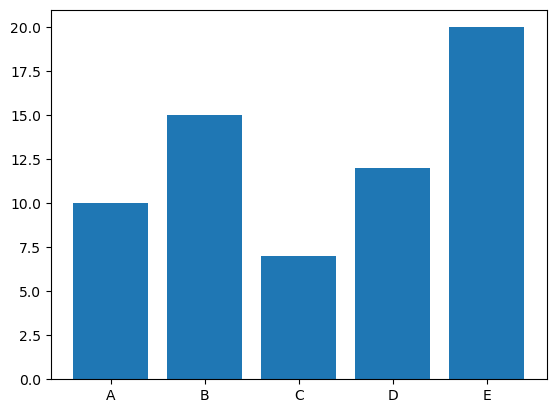

In [51]:
import matplotlib.pyplot as plt 
# import numpy as np
# Let's create simple bar plot 

x = ['A', 'B', 'C', 'D', 'E']
y = [10, 15, 7, 12, 20]
plt.bar(x, y)


# Graph Aesthetics

Almost all the graph aesthetics that we have seen with the line plot also apply to the bar plot. For instance, we can define the color of the bars in the same way we define the color of the lines.

We can also add a nice title to the graph and labels to the axes. However, bar plots have two particular aesthetic elements that are unique: the **width** and the **orientation** of the bars.

### Bar Width

To define the width of a bar, we pass a value to the `width` parameter when calling `plt.bar()`:

```python
plt.bar(x, y, width=0.5)
```

The width is given as a fraction of the x-axis unit, **not in centimeters**. This value determines how wide the bars are relative to the x-axis spacing. A value of `1` would make the bars touch each other when the x-axis values are sequential integers.



### Bar Orientation

Sometimes the best orientation for a bar plot is not vertical, but horizontal. In such cases, we generate the plot by calling `plt.barh()`.

Note that in this scenario, we don't specify a width but a **height** to define the thickness of the bar.


### Edge Color

A nice feature for bar plots is to have color on the edge of the bars. This is particularly interesting when you have grouped bars since it helps us differentiate between the distinct bars.

To define the color of the edge, we use the variable `edgecolor`:

```python
plt.bar(x, y1, width=bar_width, edgecolor='black')
```

### Grid Lines

As in the line plot, we can also define grids for our bar plot. However, the default grid is not ideal for bar plots. A nice option is to use a distinct color and linestyle (similar to MATLAB style). To do that, we can use:

```python
# Add grid lines similar to MATLAB style
plt.grid(color='white', linestyle='-', linewidth=2)
plt.gca().set_axisbelow(True)  # Ensure grid lines are behind the bars
plt.gca().set_facecolor('#E5E5E5')  # Set the axes background color
```




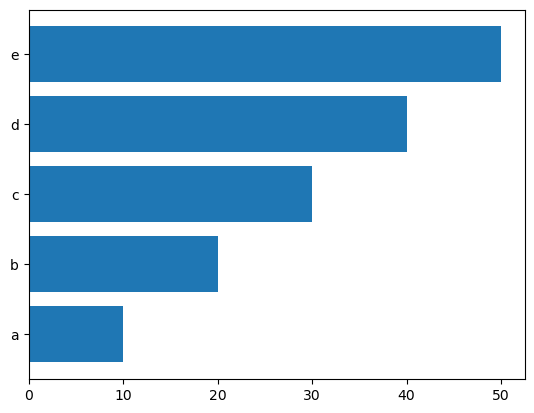

In [52]:
# Exemplo of Horizontal bar plot
import matplotlib.pyplot as plt 

x = [1, 2, 3, 4, 5]
y = [10, 20, 30, 40, 50]

plt.barh(x, y)

new_y = ['a', 'b', 'c', 'd', 'e']
plt.yticks(x, new_y)

plt.show()


## Grouped Bars

Grouped bar charts, also known as clustered bar charts, are a type of bar chart that allows for the comparison of more than one data series within the same chart. This type of visualization is particularly useful when you want to show differences between categories, as well as differences within those categories across multiple variables.

One of the challenges when working with grouped bars is the position and placement of the bars. This placement operation involves defining the positions for each bar and renaming the axis ticks. With Matplotlib, we can use the operations below to do that.

### Using NumPy to Facilitate Vectorial Operations

When working with grouped bar plots, we need to generate distinct values for the x-axis to place the bars in the plot. This is necessary because if all bars share the same x-axis values, they will be placed one behind the other. A very common strategy is to combine the bar width with a NumPy array. In this way, we can easily define the x-values for the other bars, since the NumPy array allows for vectorial operations.

For instance, let's say we need to add a group bar chart whose x-values are `x1 = [1, 2, 3]` and the bar width is 0.3.

Thus, the first bar will be placed at the original x-values, and the second will be placed at `x2 = [1.3, 2.3, 3.3]`. To generate `x2` easily in our code, we can do the following:

```python
import numpy as np

x1 = np.array([1, 2, 3])
x2 = x1 + 0.3
```

### Renaming Axes

When working with multiple bars per value, or a grouped bar plot, it is very common to rename ticks. This is necessary to improve the readability of the plot by defining a name for a specific tick on an axis that will represent the group of bars.

To do this in Matplotlib, we use the `plt.xticks` (or `plt.yticks`) function. This function receives two lists: a list with the positions of the ticks and a list with the names (or values) that will be assigned to these ticks.

See the example below:

```python
import matplotlib.pyplot as plt

x = [1, 2, 3, 4]
new_x = ['A', 'B', 'C', 'D']

plt.xticks(x, new_x)
```

In [53]:
import matplotlib.pyplot as plt 
import numpy as np

# Let's create a simple grouped bar chart.

plt.figure(figsize=(10, 5))

x = [1, 2, 3, 4, 5] 

y1 = [20, 30, 40, 50, 60]
y2 = [10, 20, 30, 40, 50]
y3 = [30, 40, 50, 60, 70]
y4 = [40, 50, 60, 70, 80]




<Figure size 1000x500 with 0 Axes>

# Activity 01

Create a *horizontal* grouped bar plot showing immigration to Canada from the following countries: Finland, Norway, and Sweden, considering only the years from 2000 to 2013.

The graph should include:

1. A title and axis labels.
2. A legend.
3. All the years placed in the correct positions in a readable way.
4. Improved visualization with a MATLAB-like grid.

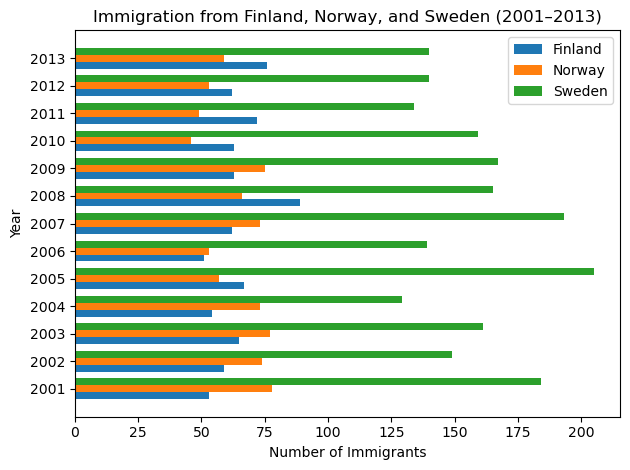

In [68]:
import matplotlib.pyplot as plt
df = pd.read_csv("Canada.csv")
df_specific = df[df['OdName'].isin(['Finland', 'Norway', 'Sweden'])]

years = list(range(2001, 2014))
countries = df_specific['OdName'].values

y_pos = list(range(len(years)))  # positions for each year
bar_height = 0.25

for i, country in enumerate(countries):
    values = df_specific[df_specific['OdName'] == country][[str(y) for y in years]].values.flatten()
    
    plt.barh(
        [y + i * bar_height for y in y_pos],
        values,
        height=bar_height,
        label=country
    )

plt.yticks([y + bar_height for y in y_pos], years)
plt.xlabel("Number of Immigrants")
plt.ylabel("Year")
plt.title("Immigration from Finland, Norway, and Sweden (2001–2013)")
plt.legend()

plt.tight_layout()
plt.show()